# Ask with a list of images

Minimal demo: send a list of images plus a text prompt to `ask_chatgpt()`.

Edit `IMAGE_PATHS` and `PROMPT` below, then run all cells.

In [1]:
print("Importing libraries...")
import sys, os
import time

sys.path.insert(0, os.path.abspath('..'))

from camera_reasoning.chatgpt_client import ask_chatgpt

Importing libraries...


## Configure images and prompt

In [5]:
IMAGE_PATHS = [
    "../reference_views_relative/view_000.png",
    "../reference_views_relative/view_009.png",
]

PROMPT = "Which side of skull do you for the first image and second image?"

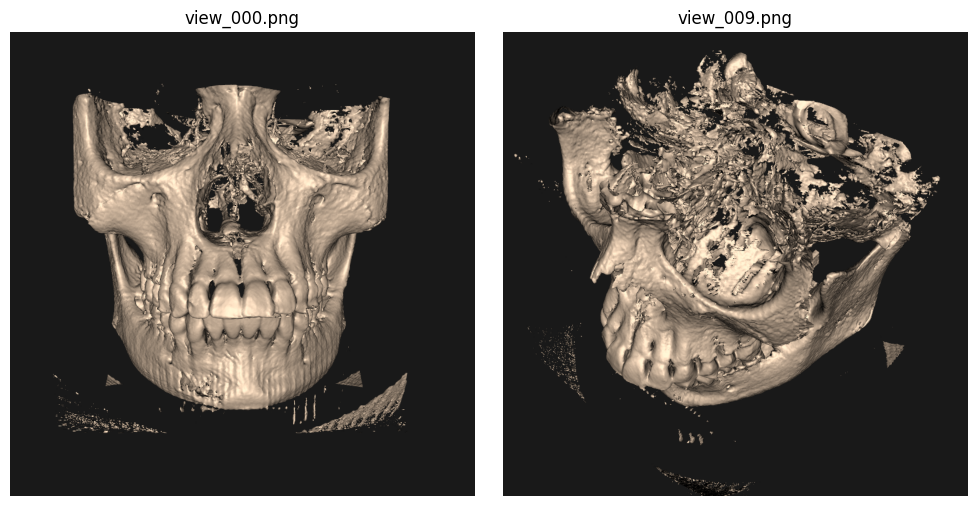

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(5 * len(IMAGE_PATHS), 5))
if len(IMAGE_PATHS) == 1:
    axes = [axes]

for ax, path in zip(axes, IMAGE_PATHS):
    ax.imshow(Image.open(path))
    ax.set_title(os.path.basename(path))
    ax.axis("off")

plt.tight_layout()
plt.show()

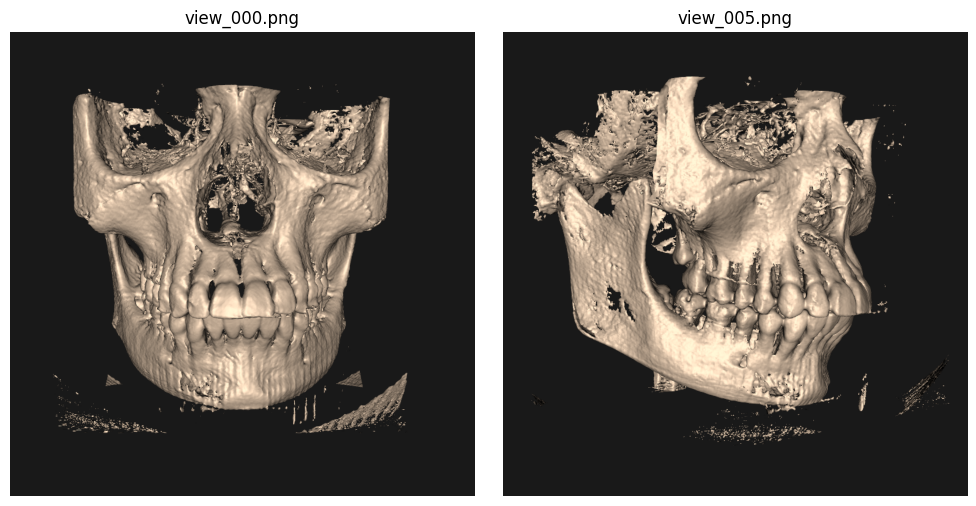

In [ ]:
# # Rotate each image 90 degrees counterclockwise and save to a temp dir;
# # ask_chatgpt() only accepts file paths, so the rotated copies are what get sent.
# import tempfile

# rotated_dir = tempfile.mkdtemp(prefix="ontovis_rotated_")
# ROTATED_IMAGE_PATHS = []

# for path in IMAGE_PATHS:
#     rotated = Image.open(path).rotate(90, expand=True)
#     out_path = os.path.join(rotated_dir, os.path.basename(path))
#     rotated.save(out_path)
#     ROTATED_IMAGE_PATHS.append(out_path)

# fig, axes = plt.subplots(1, len(ROTATED_IMAGE_PATHS), figsize=(5 * len(ROTATED_IMAGE_PATHS), 5))
# if len(ROTATED_IMAGE_PATHS) == 1:
#     axes = [axes]

# for ax, path in zip(axes, ROTATED_IMAGE_PATHS):
#     ax.imshow(Image.open(path))
#     ax.set_title(os.path.basename(path))
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

## Run

In [7]:
# ask_chatgpt() takes one required screenshot_path plus an optional list of
# (label, path) pairs for any additional images, so split the list accordingly.
screenshot_path, *rest = IMAGE_PATHS
extra_images = [(f"image_{i + 2}", path) for i, path in enumerate(rest)]

print("LLM starts processing...")
start = time.perf_counter()
response = ask_chatgpt(prompt=PROMPT, screenshot_path=screenshot_path, extra_images=extra_images)
elapsed = time.perf_counter() - start

print(response)
print(f"\n[Elapsed: {elapsed:.2f}s]")

LLM starts processing...
The first image shows a front view of a skull. The second image is from the right side of the skull, viewed at an angle that includes parts of the top and front.

[Elapsed: 3.24s]
